# Notebook 02 — Exploratory Data Analysis (EDA) & Visualizations

This notebook explores the pharmacy sales datasets to understand:
	•	Trends over time
	•	Seasonality (daily, weekly, monthly)
	•	Hourly behavior
	•	Correlations between medicine categories
	•	Distribution of sales
	•	Outliers
	•	Weekly & monthly heatmaps

The insights from this notebook will guide later forecasting models.

## 🧩 Code Cell: Import Libraries & Load Clean Data

In [1]:
# ===============================
# Import required libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 📥 Load cleaned datasets from Notebook 01

In [2]:
# Load cleaned data files generated earlier
daily = pd.read_csv("outputs/cleaned/daily_cleaned.csv")
weekly = pd.read_csv("outputs/cleaned/weekly_cleaned.csv")
monthly = pd.read_csv("outputs/cleaned/monthly_cleaned.csv")
hourly = pd.read_csv("outputs/cleaned/hourly_cleaned.csv")

# Convert dates
daily['datum'] = pd.to_datetime(daily['datum'])
weekly['datum'] = pd.to_datetime(weekly['datum'])
monthly['datum'] = pd.to_datetime(monthly['datum'])
hourly['datum'] = pd.to_datetime(hourly['datum'])

daily.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name,Day,Weekday,Weekday_Name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday,2,3,Thursday
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday,3,4,Friday
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday,4,5,Saturday
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday,5,6,Sunday
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday,6,0,Monday


## 📊 Section 1 — Summary Statistics

In [3]:
# Summary of datasets
print("Daily shape:", daily.shape)
print("Weekly shape:", weekly.shape)
print("Monthly shape:", monthly.shape)
print("Hourly shape:", hourly.shape)

daily.describe()

Daily shape: (2106, 16)
Weekly shape: (302, 14)
Monthly shape: (70, 14)
Hourly shape: (50532, 16)


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Day,Weekday
count,2106,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,2016-11-19 12:00:00.000000256,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869,15.686135,3.000475
min,2014-01-02 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000,1.000000,0.000000
25%,2015-06-12 06:00:00,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000,8.000000,1.000000
50%,2016-11-19 12:00:00,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000,16.000000,3.000000
75%,2018-04-29 18:00:00,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000,23.000000,5.000000
max,2019-10-08 00:00:00,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000,31.000000,6.000000
std,NaN,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547,8.806215,2.000831


## 📈 Section 2 — Daily Sales Trend Over Time

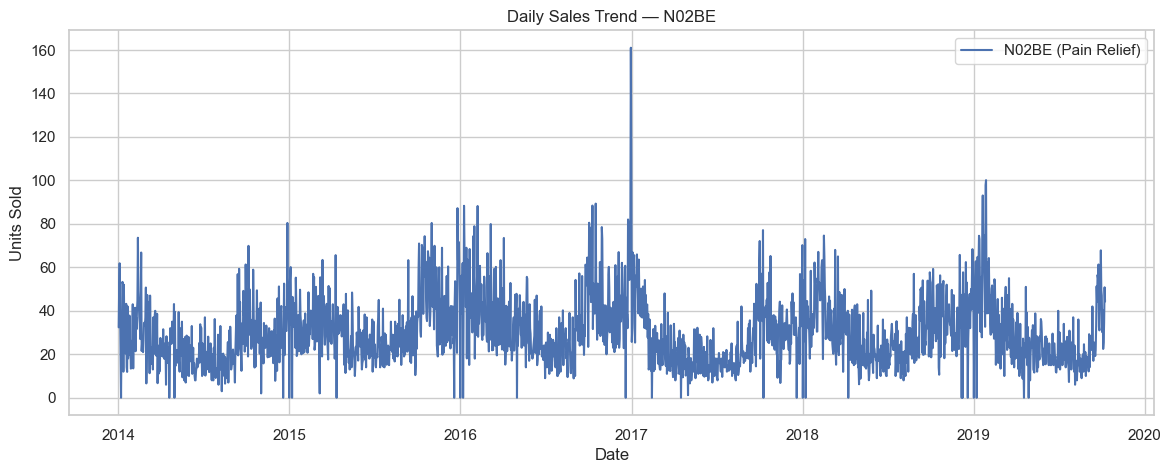

In [4]:
plt.figure(figsize=(14,5))
plt.plot(daily['datum'], daily['N02BE'], label="N02BE (Pain Relief)")
plt.title("Daily Sales Trend — N02BE")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

## 📦 Section 3 — Compare All Medicine Categories (Daily)

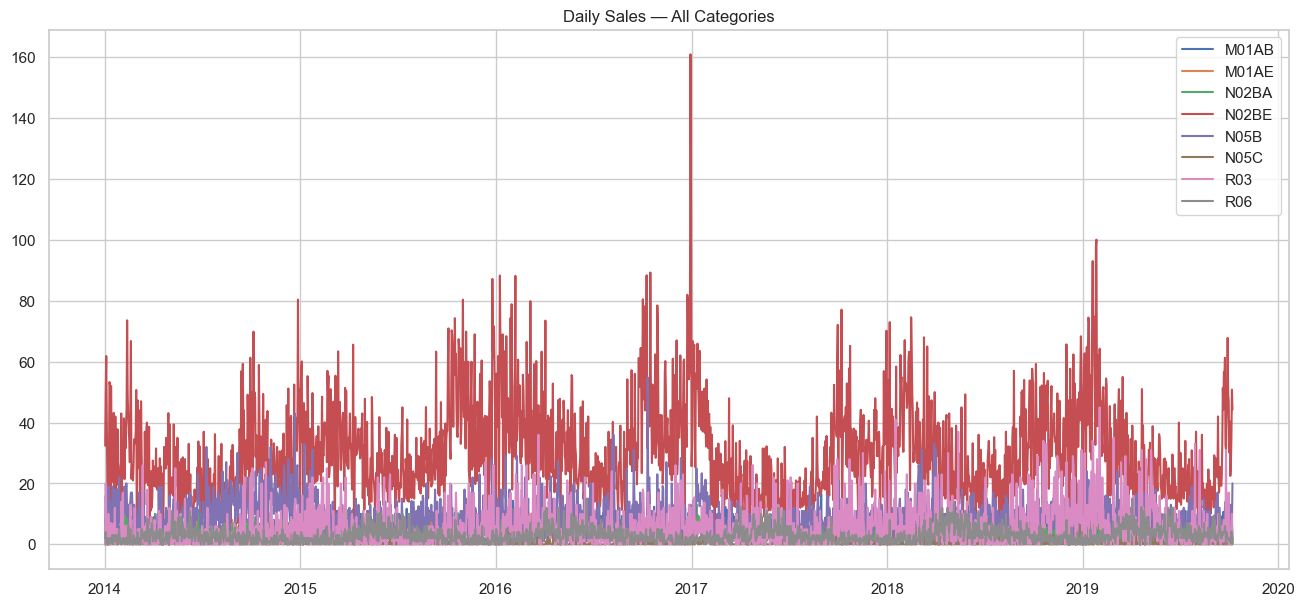

In [5]:
medicine_cols = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

plt.figure(figsize=(16,7))

for col in medicine_cols:
    plt.plot(daily['datum'], daily[col], label=col)

plt.title("Daily Sales — All Categories")
plt.legend()
plt.show()

## 📅 Section 4 — Weekly Seasonality (Which weekdays sell most?)

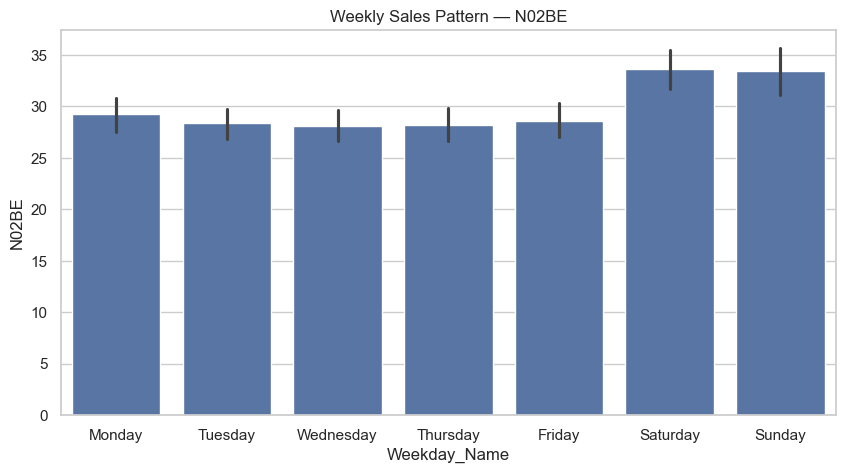

In [6]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=daily,
    x="Weekday_Name",
    y="N02BE",
    order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)
plt.title("Weekly Sales Pattern — N02BE")
plt.show()

## 🔥 Section 5 — Hourly Heatmap (Which hours perform best?)

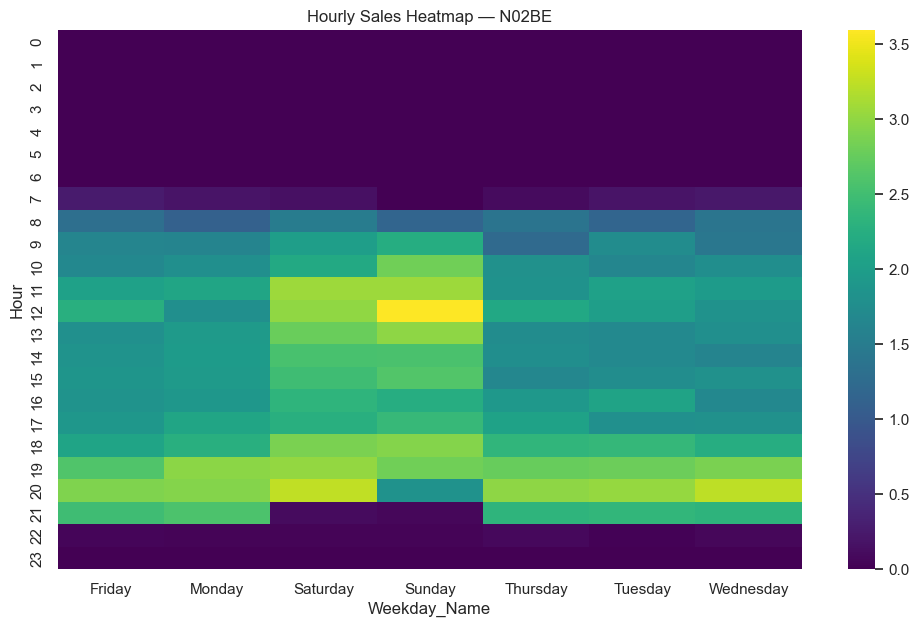

In [7]:
# Create pivot table of Hour vs Weekday
hourly_pivot = hourly.pivot_table(
    index="Hour", columns="Weekday_Name", values="N02BE", aggfunc="mean"
)

plt.figure(figsize=(12,7))
sns.heatmap(hourly_pivot, cmap="viridis")
plt.title("Hourly Sales Heatmap — N02BE")
plt.show()

## 📦 Section 6 — Correlation Between Medicine Categories

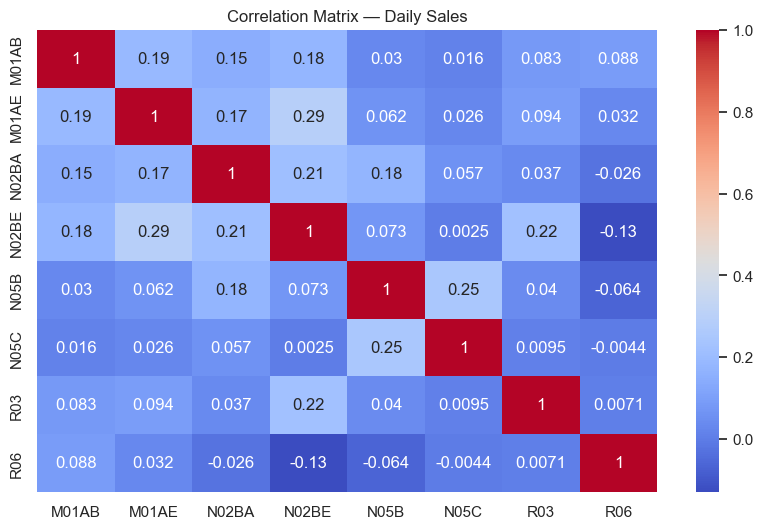

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(daily[medicine_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix — Daily Sales")
plt.show()

## 📊 Section 7 — Distribution of Daily Sales

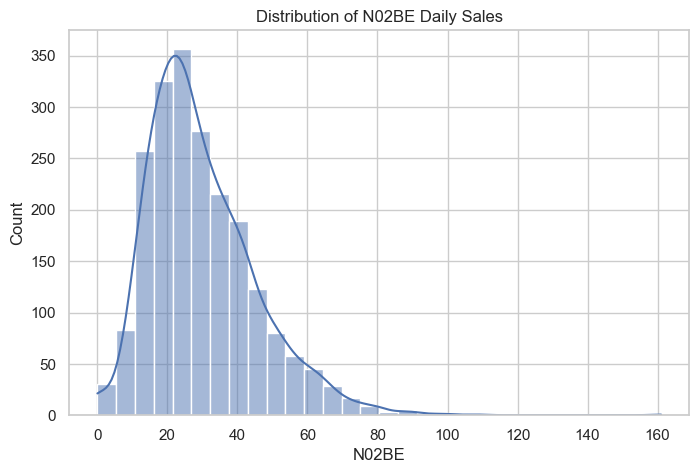

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(daily["N02BE"], bins=30, kde=True)
plt.title("Distribution of N02BE Daily Sales")
plt.show()

## 🧭 Section 8 — Rolling Mean (Trend Smoothing)

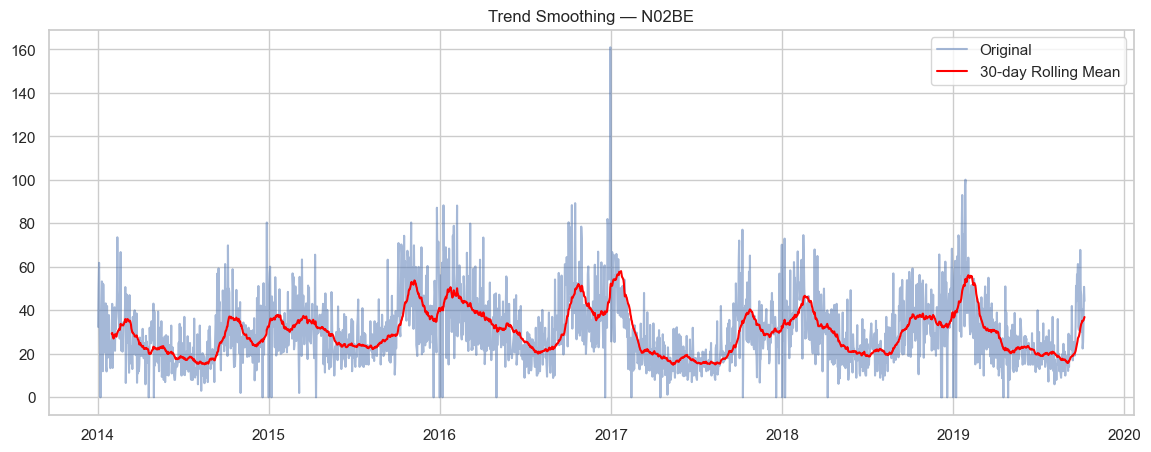

In [10]:
daily['N02BE_roll'] = daily['N02BE'].rolling(window=30).mean()

plt.figure(figsize=(14,5))
plt.plot(daily['datum'], daily['N02BE'], alpha=0.5, label="Original")
plt.plot(daily['datum'], daily['N02BE_roll'], color="red", label="30-day Rolling Mean")
plt.title("Trend Smoothing — N02BE")
plt.legend()
plt.show()

## 📆 Section 9 — Monthly Trends

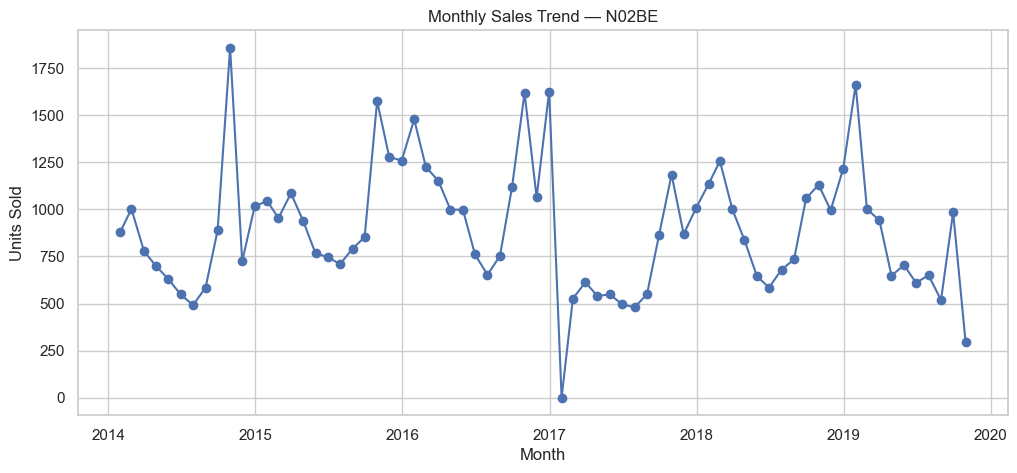

In [11]:
plt.figure(figsize=(12,5))
plt.plot(monthly['datum'], monthly['N02BE'], marker="o")
plt.title("Monthly Sales Trend — N02BE")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()

## 💾 Final Step — Save Figures (Optional)

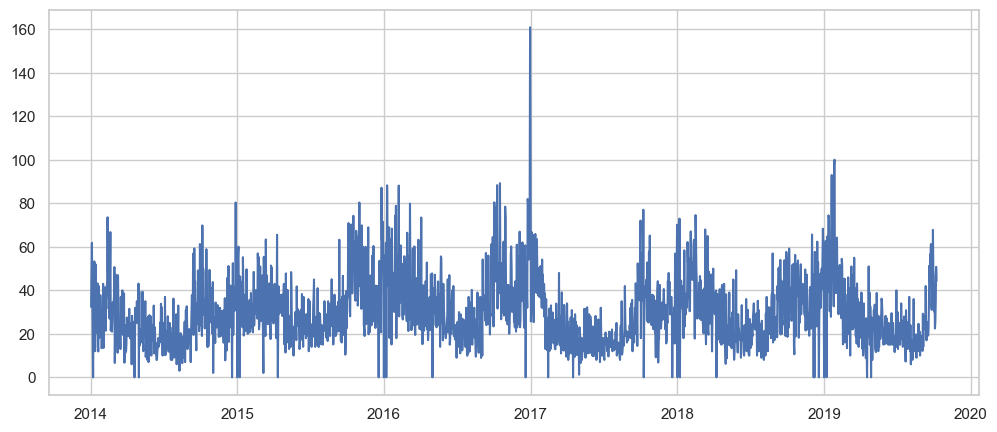

In [12]:
os.makedirs("outputs/figures", exist_ok=True)

plt.figure(figsize=(12,5))
plt.plot(daily['datum'], daily['N02BE'])
plt.savefig("outputs/figures/daily_trend_N02BE.png", dpi=300)